# Worthly — Laptop Price Prediction


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)

In [2]:
from google.colab import drive
drive.mount('/content/mydrive')

Mounted at /content/mydrive


In [3]:
file_path = "/content/mydrive/MyDrive/Project:WORTHLY/laptop_data.csv"

df = pd.read_csv(file_path)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

In [4]:
df.shape

(1303, 11)

In [5]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [6]:
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)

Columns: ['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price']

Missing values:
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

Duplicate rows: 29


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company,1303,19,Dell,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TypeName,1303,6,Notebook,727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inches,1303.0,NaN,NaN,NaN,15.017191,1.426304,10.1,14.0,15.6,15.6,18.4
ScreenResolution,1303,40,Full HD 1920x1080,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cpu,1303,118,Intel Core i5 7200U 2.5GHz,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ram,1303,9,8GB,619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory,1303,39,256GB SSD,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gpu,1303,110,Intel HD Graphics 620,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OpSys,1303,9,Windows 10,1072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight,1303,179,2.2kg,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##Feature Engineering

In [7]:
df["Ram"] = df["Ram"].astype(str).str.replace("GB", "", regex=False).astype(int)
df["Weight"] = df["Weight"].astype(str).str.replace("kg", "", regex=False).astype(float)

df["Touchscreen"] = df["ScreenResolution"].astype(str).str.contains(
    "Touchscreen", case=False, na=False
).astype(int)

df["Ips"] = df["ScreenResolution"].astype(str).str.contains(
    "IPS", case=False, na=False
).astype(int)

resolution = df["ScreenResolution"].astype(str).str.extract(r"(\d{3,4})x(\d{3,4})")
df["X_res"] = pd.to_numeric(resolution[0], errors="coerce")
df["Y_res"] = pd.to_numeric(resolution[1], errors="coerce")
df["ppi"] = np.sqrt(df["X_res"]**2 + df["Y_res"]**2) / df["Inches"]

def cpu_brand(cpu):
    cpu = str(cpu)
    if "Intel Core i7" in cpu:
        return "Intel Core i7"
    if "Intel Core i5" in cpu:
        return "Intel Core i5"
    if "Intel Core i3" in cpu:
        return "Intel Core i3"
    if "Intel" in cpu:
        return "Other Intel Processor"
    return "AMD Processor"

df["Cpu brand"] = df["Cpu"].apply(cpu_brand)
df["Gpu brand"] = df["Gpu"].astype(str).str.split().str[0]
df = df[df["Gpu brand"].isin(["AMD", "Intel", "Nvidia"])].copy()

def os_group(value):
    value = str(value)
    if value in ["Windows 10", "Windows 7", "Windows 10 S"]:
        return "Windows"
    if value in ["macOS", "Mac OS X"]:
        return "Mac"
    return "Others/No OS/Linux"

df["os"] = df["OpSys"].apply(os_group)

print("Rows after initial feature engineering:", len(df))

Rows after initial feature engineering: 1302


In [8]:
def storage_to_gb(value):
    value = str(value).strip()
    if "TB" in value:
        return int(float(value.replace("TB", "").strip()) * 1000)
    if "GB" in value:
        return int(float(value.replace("GB", "").strip()))
    return 0

def extract_storage(memory):
    hdd, ssd = 0, 0
    for part in str(memory).split("+"):
        part = part.strip()
        if "HDD" in part:
            hdd += storage_to_gb(part.replace("HDD", ""))
        elif "SSD" in part:
            ssd += storage_to_gb(part.replace("SSD", ""))
    return pd.Series([hdd, ssd])

df[["HDD", "SSD"]] = df["Memory"].apply(extract_storage)

print("Final processed rows:", len(df))
display(df.head())

Final processed rows: 1302


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res,ppi,Cpu brand,Gpu brand,os,HDD,SSD
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005,Intel Core i5,Intel,Mac,0,128
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940,Intel Core i5,Intel,Mac,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998,Intel Core i5,Intel,Others/No OS/Linux,0,256
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624,Intel Core i7,AMD,Mac,0,512
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005,Intel Core i5,Intel,Mac,0,256


#Features and Target


In [9]:
FEATURES = [
    "Company", "TypeName", "Ram", "Weight", "Touchscreen", "Ips",
    "ppi", "HDD", "SSD", "Cpu brand", "Gpu brand", "os"
]

X = df[FEATURES].copy()
y = np.log(df["Price"].astype(float))

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (1302, 12)
y shape: (1302,)


,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,HDD,SSD,Cpu brand,Gpu brand,os
0,Apple,Ultrabook,8,1.37,0,1,226.983005,0,128,Intel Core i5,Intel,Mac
1,Apple,Ultrabook,8,1.34,0,0,127.677940,0,0,Intel Core i5,Intel,Mac
2,HP,Notebook,8,1.86,0,0,141.211998,0,256,Intel Core i5,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,0,1,220.534624,0,512,Intel Core i7,AMD,Mac
4,Apple,Ultrabook,8,1.37,0,1,226.983005,0,256,Intel Core i5,Intel,Mac


## Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=2
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1106
Testing rows: 196


##Preprocessing and Random Forest

In [11]:
categorical_features = [
    "Company", "TypeName", "Cpu brand", "Gpu brand", "os"
]

numerical_features = [
    "Ram", "Weight", "Touchscreen", "Ips", "ppi", "HDD", "SSD"
]

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numerical", "passthrough", numerical_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=2,
        n_jobs=-1
    )),
])

pipeline.fit(X_train, y_train)
print("Training complete.")

Training complete.


## Evaluation

In [12]:
log_predictions = pipeline.predict(X_test)

actual_prices = np.exp(y_test.to_numpy())
predicted_prices = np.exp(log_predictions)

r2 = r2_score(y_test, log_predictions)
log_mae = mean_absolute_error(y_test, log_predictions)
price_mae = mean_absolute_error(actual_prices, predicted_prices)
price_rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

print(f"R²:        {r2:.4f}")
print(f"Log MAE:   {log_mae:.4f}")
print(f"Price MAE: Rs. {price_mae:,.2f}")
print(f"RMSE:      Rs. {price_rmse:,.2f}")

R²:        0.8901
Log MAE:   0.1532
Price MAE: Rs. 8,713.93
RMSE:      Rs. 13,596.50


In [13]:
cv = KFold(n_splits=5, shuffle=True, random_state=2)

cv_r2 = cross_val_score(
    pipeline, X, y, cv=cv, scoring="r2", n_jobs=-1
)

print("Fold R² scores:", np.round(cv_r2, 4))
print(f"Mean CV R²: {cv_r2.mean():.4f}")
print(f"Standard deviation: {cv_r2.std():.4f}")

Fold R² scores: [0.8613 0.8567 0.8861 0.8905 0.895 ]
Mean CV R²: 0.8779
Standard deviation: 0.0157


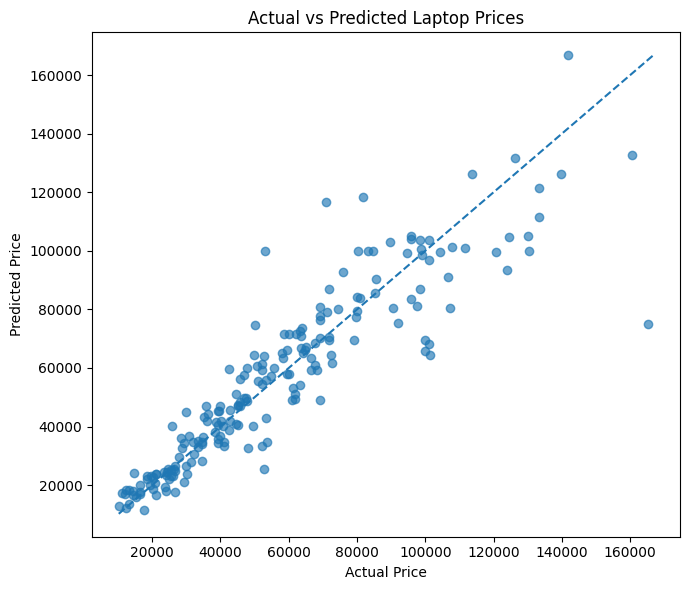

In [14]:
plt.figure(figsize=(7, 6))
plt.scatter(actual_prices, predicted_prices, alpha=0.65)

low = min(actual_prices.min(), predicted_prices.min())
high = max(actual_prices.max(), predicted_prices.max())
plt.plot([low, high], [low, high], linestyle="--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Laptop Prices")
plt.tight_layout()
plt.show()

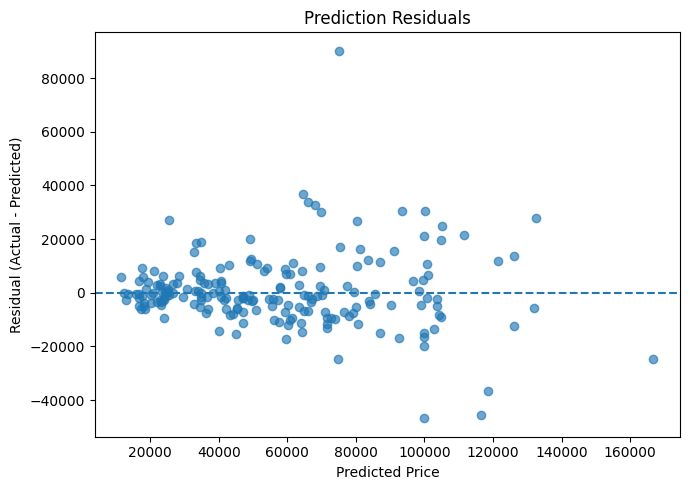

Median absolute error: Rs. 5,875.66


In [15]:
residuals = actual_prices - predicted_prices

plt.figure(figsize=(7, 5))
plt.scatter(predicted_prices, residuals, alpha=0.65)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Prediction Residuals")
plt.tight_layout()
plt.show()

print(f"Median absolute error: Rs. {np.median(np.abs(residuals)):,.2f}")

In [16]:
results = X_test.copy()
results["Actual Price"] = actual_prices
results["Predicted Price"] = predicted_prices
results["Absolute Error"] = np.abs(actual_prices - predicted_prices)

display(
    results[[
        "Company", "TypeName", "Ram", "SSD", "Cpu brand",
        "Actual Price", "Predicted Price", "Absolute Error"
    ]].head(10).round(2)
)

,Company,TypeName,Ram,SSD,Cpu brand,Actual Price,Predicted Price,Absolute Error
248,HP,Notebook,4,0,Intel Core i5,35964.00,42019.63,6055.63
555,Asus,Notebook,4,0,Other Intel Processor,11934.72,16892.88,4958.16
1251,HP,Notebook,4,0,AMD Processor,21258.72,16706.35,4552.37
547,Lenovo,Notebook,4,0,Intel Core i5,24634.01,25365.22,731.21
885,HP,2 in 1 Convertible,4,256,Intel Core i5,95850.72,83585.61,12265.11
761,Dell,Ultrabook,16,256,Intel Core i7,99047.52,98481.61,565.91
333,Lenovo,Notebook,4,0,Intel Core i3,23922.72,23463.85,458.87
733,Acer,Notebook,4,0,Intel Core i5,29783.52,45102.06,15318.54
653,MSI,Gaming,8,128,Intel Core i7,63499.10,66965.42,3466.31
1198,Acer,Notebook,4,0,Other Intel Processor,14492.16,16631.31,2139.15


In [17]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=2,
        n_jobs=-1
    )),
])

final_model.fit(X, y)
print("Final model trained on", len(X), "records.")

Final model trained on 1302 records.


##Exporting the Pickle Model

In [18]:
with open("laptop_price_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Saved laptop_price_model.pkl")

Saved laptop_price_model.pkl


In [19]:
with open("laptop_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

sample = X.iloc[[0]]
sample_prediction = np.exp(loaded_model.predict(sample)[0])

display(sample)
print(f"Predicted price: Rs. {sample_prediction:,.2f}")
print(f"Actual price:    Rs. {df.iloc[0]['Price']:,.2f}")

,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,HDD,SSD,Cpu brand,Gpu brand,os
0,Apple,Ultrabook,8,1.37,0,1,226.983005,0,128,Intel Core i5,Intel,Mac


Predicted price: Rs. 70,655.42
Actual price:    Rs. 71,378.68
